#NETFLIX CONTENT VISUALIZATION

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
from google.colab import files
uploaded = files.upload()
df= pd.read_csv("netflix_titles.csv")

Saving netflix_titles.csv to netflix_titles (1).csv


In [10]:
df.head()
df.info()
df.shape
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6234 entries, 0 to 6233
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       6234 non-null   int64 
 1   type          6234 non-null   object
 2   title         6234 non-null   object
 3   director      4265 non-null   object
 4   cast          5664 non-null   object
 5   country       5758 non-null   object
 6   date_added    6223 non-null   object
 7   release_year  6234 non-null   int64 
 8   rating        6224 non-null   object
 9   duration      6234 non-null   object
 10  listed_in     6234 non-null   object
 11  description   6234 non-null   object
dtypes: int64(2), object(10)
memory usage: 584.6+ KB


,show_id,release_year
count,6.234000e+03,6234.00000
mean,7.670368e+07,2013.35932
std,1.094296e+07,8.81162
min,2.477470e+05,1925.00000
25%,8.003580e+07,2013.00000
50%,8.016337e+07,2016.00000
75%,8.024489e+07,2018.00000
max,8.123573e+07,2020.00000


In [11]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,1969
cast,570
country,476
date_added,11
release_year,0
rating,10
duration,0


In [12]:
df['director'] = df['director'].fillna('Unknown')

df['cast'] = df['cast'].fillna('Unknown')

df['country'] = df['country'].fillna('Unknown')

df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

df['duration'] = df['duration'].fillna('Unknown')

In [13]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,11
release_year,0
rating,0
duration,0


In [14]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

###Movies vs TV Shows

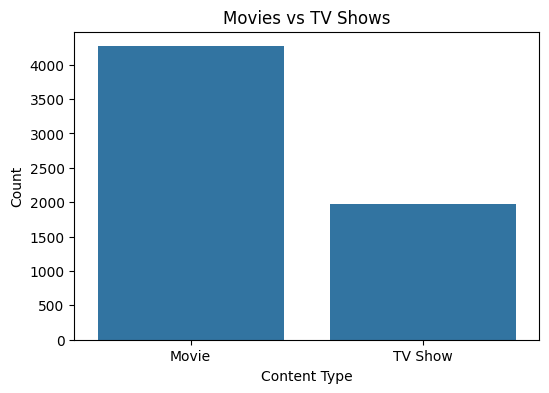

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

###Top 10 Countries Producing Netflix Content

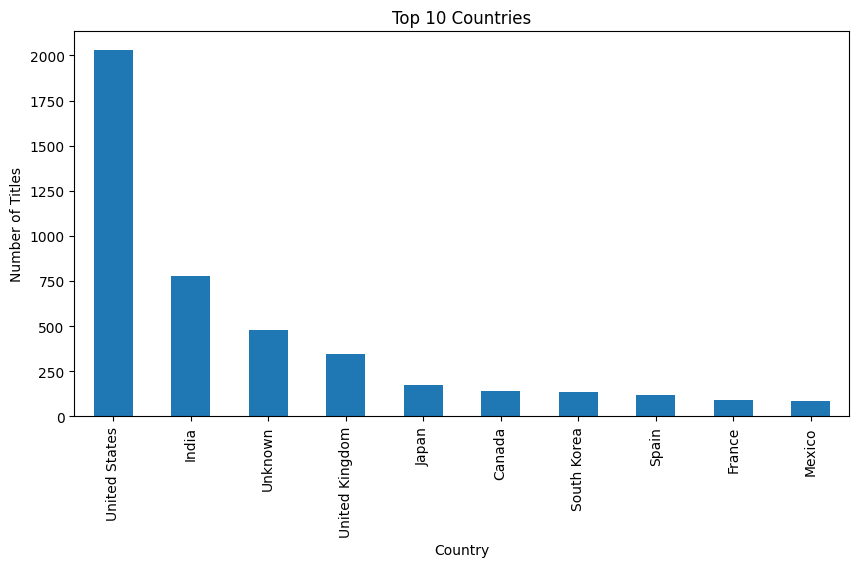

In [16]:
plt.figure(figsize=(10,5))

df['country'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Countries")

plt.xlabel("Country")

plt.ylabel("Number of Titles")

plt.show()

###Content Released by Year

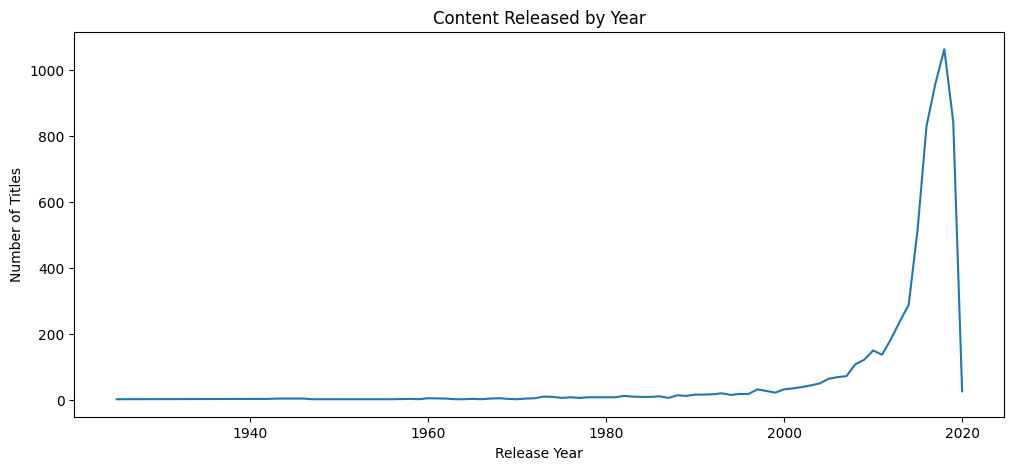

In [17]:
plt.figure(figsize=(12,5))

df['release_year'].value_counts().sort_index().plot()

plt.title("Content Released by Year")

plt.xlabel("Release Year")

plt.ylabel("Number of Titles")

plt.show()

###Top 10 Genres

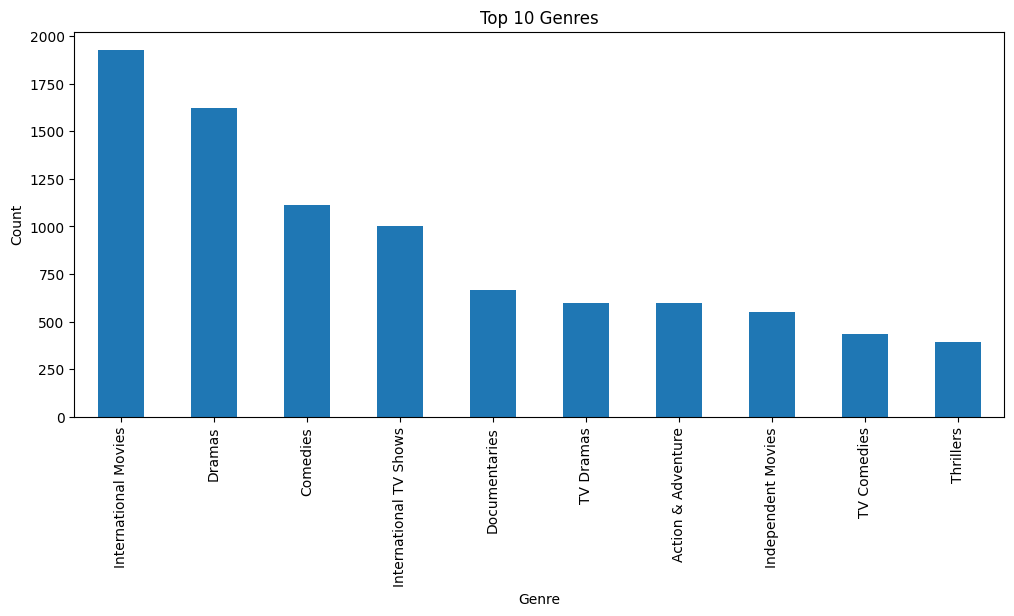

In [18]:
plt.figure(figsize=(12,5))

df['listed_in'].str.split(', ').explode().value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Genres")

plt.xlabel("Genre")

plt.ylabel("Count")

plt.show()

###Ratings Distribution

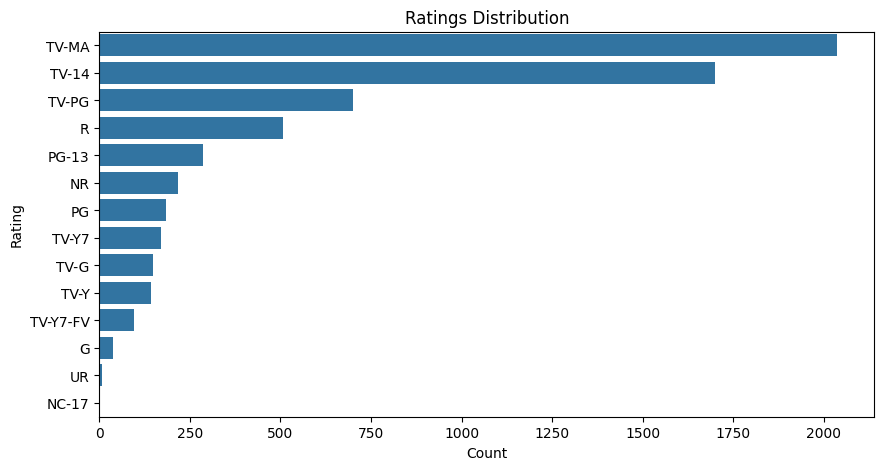

In [19]:
plt.figure(figsize=(10,5))

sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index)

plt.title("Ratings Distribution")

plt.xlabel("Count")

plt.ylabel("Rating")

plt.show()

###Movie Duration Distribution

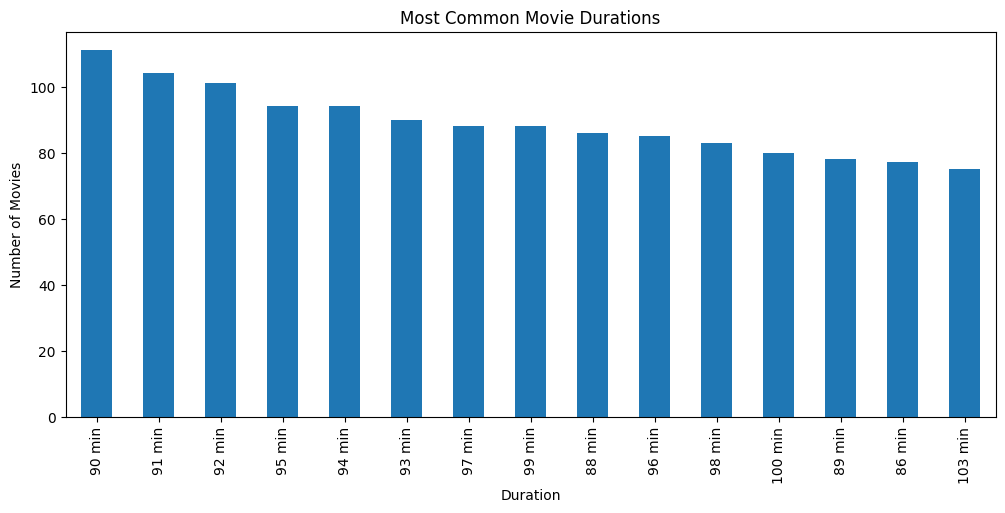

In [20]:
movies = df[df['type']=='Movie']

plt.figure(figsize=(12,5))

movies['duration'].value_counts().head(15).plot(kind='bar')

plt.title("Most Common Movie Durations")

plt.xlabel("Duration")

plt.ylabel("Number of Movies")

plt.show()

###Correlation Heatmap

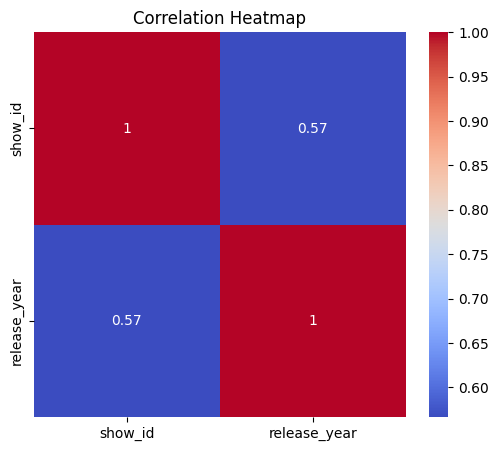

In [21]:
plt.figure(figsize=(6,5))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()